In [1]:
import numpy as np
import numpy.linalg as npla
import matplotlib.pyplot as plt
import networkx as nx
from sklearn import datasets


# PCA and PageRank

Two applications that sit on top of the same core tool: eigendecomposition / SVD.


---
## Part 1: Principal Component Analysis (PCA)

### Covariance matrix

Given a data matrix $D \in \mathbb{R}^{n \times p}$ (n samples, p features), center it:

$$Z = D - \mathbf{1}\mu^T, \qquad \mu_j = \frac{1}{n}\sum_{i=1}^n D_{ij}.$$

The **covariance matrix** is

>$$C = \frac{1}{n} Z^T Z \in \mathbb{R}^{p \times p}.$$

$C$ is **symmetric positive semi-definite** (SPSD): $C = C^T$ and $x^TCx \ge 0$ for all $x$.  
Because $C$ is SPSD, its eigenvalues are its singular values and $U = V$ in the SVD.


In [2]:
# Toy example: 3 samples, 3 features
D = np.array([[2, 0, 2], [4, 1, 4], [0, 1, 1]], dtype=float)
Z = D - D.mean(axis=0)
C = (Z.T @ Z) / D.shape[0]

print(f"C =\n{C}")
print(f"Symmetric: {np.allclose(C, C.T)}")
print(f"Rank:      {npla.matrix_rank(C)}")


C =
[[2.66666667 0.         2.        ]
 [0.         0.22222222 0.11111111]
 [2.         0.11111111 1.55555556]]
Symmetric: True
Rank:      2


### Principal components

The columns of $U$ from the SVD $C = U \Sigma U^T$ are the **principal components**. The $i$-th eigenvalue $\sigma_i$ is the variance explained by $\text{PC}_i$.


In [3]:
U, sigma, _ = npla.svd(C)
print(f"Singular values (eigvals of C): {sigma.round(4)}")
print(f"Variance explained (%):        {(100 * sigma / sigma.sum()).round(2)}")


Singular values (eigvals of C): [4.188  0.2565 0.    ]
Variance explained (%):        [94.23  5.77  0.  ]


### Dimensionality reduction

Project each centered sample onto the first $k$ principal components:

>$$\text{scores} = Z U^{(k)} \in \mathbb{R}^{n \times k}$$

Reconstruct:

$$D^{(k)} \approx M + Z U^{(k)} \left(U^{(k)}\right)^T$$

where $M$ has $\mu^T$ stacked $n$ times. Using all $p$ components recovers $D$ exactly.


### Full example: Iris dataset (150 samples, 4 features)


In [4]:
iris = datasets.load_iris()
D, y = iris.data, iris.target
n, p = D.shape

mu = D.mean(axis=0)
Z  = D - mu
C  = np.cov(Z.T)

U, sigma, _ = npla.svd(C)
print("Variance explained per PC (%):", np.round(100 * sigma / sigma.sum(), 2))


Variance explained per PC (%): [92.46  5.31  1.71  0.52]


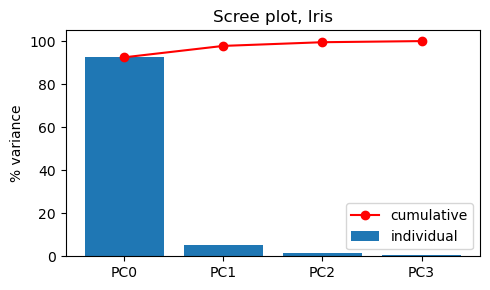

In [5]:
cumvar = np.cumsum(sigma) / sigma.sum() * 100
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([f'PC{i}' for i in range(p)], 100 * sigma / sigma.sum(), label='individual')
ax.plot([f'PC{i}' for i in range(p)], cumvar, 'r-o', label='cumulative')
ax.set_ylabel('% variance')
ax.set_title('Scree plot, Iris')
ax.legend()
plt.tight_layout()
plt.show()


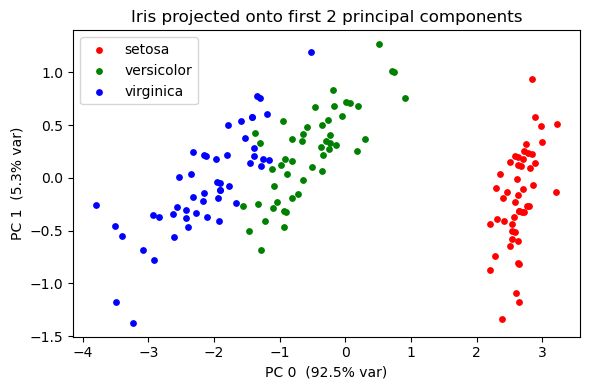

In [6]:
scores = Z @ U[:, :2]

fig, ax = plt.subplots(figsize=(6, 4))
for cls, (color, label) in enumerate(zip(['r','g','b'], iris.target_names)):
    mask = y == cls
    ax.scatter(scores[mask, 0], scores[mask, 1], c=color, s=15, label=label)
ax.set_xlabel('PC 0  (92.5% var)')
ax.set_ylabel('PC 1  (5.3% var)')
ax.set_title('Iris projected onto first 2 principal components')
ax.legend()
plt.tight_layout()
plt.show()


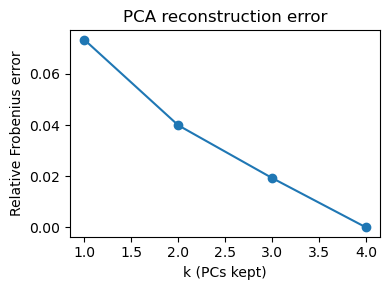

In [7]:
M_mat = np.ones((n, 1)) @ mu.reshape(1, -1)
errs  = [npla.norm(D - (M_mat + (Z @ U[:, :k]) @ U[:, :k].T), 'fro') / npla.norm(D, 'fro')
         for k in range(1, p + 1)]

plt.figure(figsize=(4, 3))
plt.plot(range(1, p + 1), errs, '-o')
plt.xlabel('k (PCs kept)')
plt.ylabel('Relative Frobenius error')
plt.title('PCA reconstruction error')
plt.tight_layout()
plt.show()


---
## Part 2: Directed Graphs and PageRank Notation

Use this PageRank convention:

>$$E_{ij}=1 \quad\Longleftrightarrow\quad j \to i.$$

Columns are source pages. The column sum is `outdegree`.


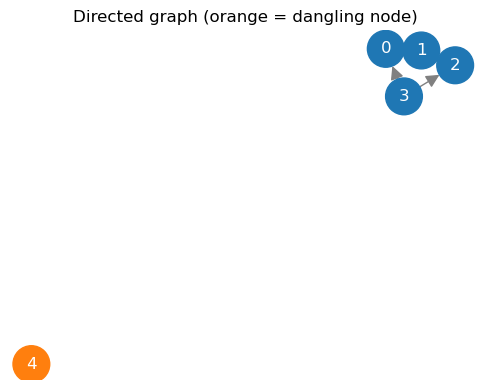

Out-degrees: {0: 2, 1: 1, 2: 1, 3: 2, 4: 0}


In [8]:
# Build a small directed graph with NetworkX
G = nx.DiGraph()
G.add_edges_from([
    (0, 1), (0, 2),   # 0 links to 1 and 2
    (1, 2),           # 1 links to 2
    (2, 0),           # 2 links back to 0
    (3, 0), (3, 2),   # 3 links to 0 and 2
    # node 4 has no outgoing edges -> DANGLING NODE
])
G.add_node(4)         # add dangling node explicitly

pos = nx.spring_layout(G, seed=7)
node_colors = ['tab:orange' if G.out_degree(v) == 0 else 'tab:blue' for v in G.nodes()]

fig, ax = plt.subplots(figsize=(5, 4))
nx.draw_networkx(G, pos, ax=ax, node_color=node_colors,
                 edge_color='gray', arrows=True, arrowsize=20,
                 node_size=700, font_color='white')
ax.set_title('Directed graph (orange = dangling node)')
ax.axis('off')
plt.tight_layout()
plt.show()

print("Out-degrees:", dict(G.out_degree()))


### Adjacency matrix

NetworkX uses $A_{ij}=1$ for $i\to j$, so transpose once:

>$$E=A_{\text{nx}}^T.$$


In [9]:
n_nodes = G.number_of_nodes()
nodes   = sorted(G.nodes())

# NetworkX: A_nx[i,j] = 1 means i->j
A_nx = nx.to_numpy_array(G, nodelist=nodes)
A_nx = np.array([[0, 0, 1, 1,], [1, 0, 0, 0], [1, 1, 0, 1], [1, 1, 0, 0]]).T

# PageRank convention: E[i,j] = 1 means j->i
E = A_nx.T
outdegree = E.sum(axis=0)

print("E =")
print(E.astype(int))
print("outdegree =", outdegree.astype(int))


E =
[[0 0 1 1]
 [1 0 0 0]
 [1 1 0 1]
 [1 1 0 0]]
outdegree = [3 2 1 2]


### From `E` to `M`

We build the PageRank matrix in three steps: handle dangling pages, form `LM`, then form `M`.


#### Dangling-node adjustment

A dangling page has no outgoing links, so its column cannot be normalized. Let

>$$\text{dangling}=\{j:\text{outdegree}[j]=0\}.$$

For each dangling column, add links to every other page:

>$$
(E_{\text{fixed}})_{ij}=\begin{cases}
1, & i\ne j,\\
0, & i=j.
\end{cases}
$$


In [10]:
def dangling_nodes(E):
    """Return the column indices with outdegree zero."""
    outdegree = E.sum(axis=0)
    return np.where(outdegree == 0)[0]


def fix_dangling_columns(E):
    """Return a copy of E with dangling columns fixed."""
    E = E.astype(float).copy()
    for j in dangling_nodes(E):
        E[:, j] = 1.0
        E[j, j] = 0.0
    return E

outdegree = E.sum(axis=0)
E_fixed = fix_dangling_columns(E)

print("outdegree:", outdegree.astype(int))
print("dangling columns:", dangling_nodes(E))
#print("fixed dangling column:", E_fixed[:, 4].astype(int))


outdegree: [3 2 1 2]
dangling columns: []


#### Link matrix `LM`

Normalize each fixed column:

>$$LM[:,j]=\frac{E_{\text{fixed}}[:,j]}{\sum_i (E_{\text{fixed}})_{ij}}.$$

Column `j` gives the probabilities for where you go next from page `j`.


In [11]:
def make_LM_from_E(E):
    """PageRank adjacency E -> link matrix LM."""
    E_fixed = fix_dangling_columns(E)
    return E_fixed / E_fixed.sum(axis=0)

LM = make_LM_from_E(E)
print("LM =")
print(np.round(LM, 3))
print("LM column sums:", np.round(LM.sum(axis=0), 3))


LM =
[[0.    0.    1.    0.5  ]
 [0.333 0.    0.    0.   ]
 [0.333 0.5   0.    0.5  ]
 [0.333 0.5   0.    0.   ]]
LM column sums: [1. 1. 1. 1.]


#### Markov matrix `M`

Add jumping to a random page:

>$$M=(1-m)LM+\frac{m}{n}\mathbf{1}\mathbf{1}^T.$$

Each column of `M` still sums to 1.


In [12]:
def make_M_from_E(E, m=0.15):
    """PageRank adjacency E -> Markov matrix M."""
    n = E.shape[0]
    LM = make_LM_from_E(E)
    return (1 - m) * LM + m * np.ones((n, n)) / n

m = 0.15
M = make_M_from_E(E, m=m)

print("M =")
print(np.round(M, 3))
print("M bottom row:", np.round(M[-1], 3))
print("M column sums:", np.round(M.sum(axis=0), 3))


M =
[[0.038 0.038 0.888 0.462]
 [0.321 0.038 0.038 0.038]
 [0.321 0.462 0.038 0.462]
 [0.321 0.462 0.038 0.038]]
M bottom row: [0.321 0.462 0.038 0.038]
M column sums: [1. 1. 1. 1.]


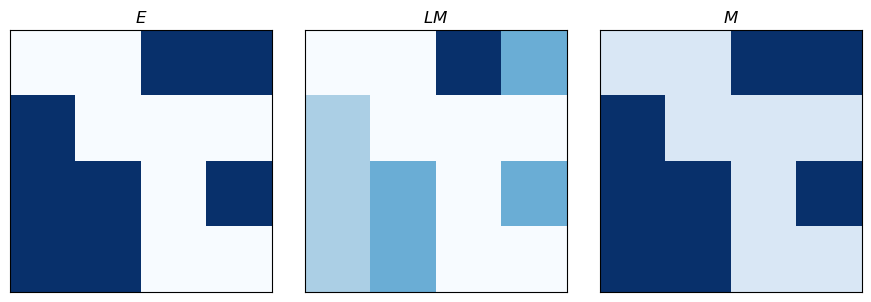

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
plots = [(E, '$E$', 1), (LM, '$LM$', 1), (M, '$M$', 0.25)]

for ax, (mat, title, vmax) in zip(axs, plots):
    ax.imshow(mat, cmap='Blues', vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


---
## Part 3: PageRank Calculation

Now compute the PageRank vector and rank pages by sorting its entries.


#### Direct eigenvector method

PageRank solves

>$$Mx=x, \qquad \|x\|_1=1.$$

For a small graph, compute the eigenvector whose eigenvalue is closest to 1.


In [14]:
def pagerank_direct(E, m=0.15):
    """Small-graph PageRank using a dense eigendecomposition."""
    M = make_M_from_E(E, m=m)
    evals, evecs = npla.eig(M)
    idx = np.argmin(np.abs(evals - 1))
    scores = evecs[:, idx].real

    if scores.sum() < 0:
        scores = -scores
    scores = np.maximum(scores, 0)
    scores = scores / scores.sum()
    ranking = np.argsort(scores)[::-1]
    return scores, ranking, evals

scores_direct, ranking_direct, evals = pagerank_direct(E)
print("eigenvalues:", np.round(evals.real, 4))
print("scores:", np.round(scores_direct, 4))
print("ranking:", ranking_direct)


eigenvalues: [ 1.     -0.3065 -0.3065 -0.2369]
scores: [0.3682 0.1418 0.288  0.2021]
ranking: [0 2 3 1]


#### Power iteration

Start uniform and repeatedly apply `M`:

>$$x^{(0)}=\frac{1}{n}\mathbf{1}, \qquad x^{(k+1)}=Mx^{(k)}.$$

Stop when $\|x^{(k+1)}-x^{(k)}\|_1$ is small.


In [15]:
def pagerank_power(M, tol=1e-10, max_iter=500):
    """Power iteration for PageRank."""
    n = M.shape[0]
    x = np.ones(n) / n

    for iteration in range(1, max_iter + 1):
        x_new = M @ x
        x_new = x_new / x_new.sum()
        if npla.norm(x_new - x, ord=1) < tol:
            break
        x = x_new

    ranking = np.argsort(x_new)[::-1]
    return x_new, ranking, iteration

scores_power, ranking_power, num_iters = pagerank_power(M)
print("scores:", np.round(scores_power, 4))
print("ranking:", ranking_power)
print("iterations:", num_iters)
print("matches direct:", np.allclose(scores_direct, scores_power, atol=1e-8))


scores: [0.3682 0.1418 0.288  0.2021]
ranking: [0 2 3 1]
iterations: 31
matches direct: True


### First few iterates

The vector quickly moves toward the PageRank scores.


In [19]:
x_iter = np.ones(n_nodes) / n_nodes
print("k=0", np.round(x_iter, 4))
for k in range(1, 1):
    x_iter = M @ x_iter
    x_iter = x_iter / x_iter.sum()
    print(f"k={k}", np.round(x_iter, 4))


k=0 [0.2 0.2 0.2 0.2 0.2]


### Dense PageRank

This wraps the dense construction and power iteration.


In [20]:
def pagerank_dense(E, m=0.15, tol=1e-10, max_iter=500):
    """Dense PageRank: build M, run power iteration, sort scores."""
    M = make_M_from_E(E, m=m)
    return pagerank_power(M, tol=tol, max_iter=max_iter)

scores_dense, ranking_dense, dense_iters = pagerank_dense(E)
print("ranking:", ranking_dense)
print("scores: ", np.round(scores_dense, 4))
print("iterations:", dense_iters)


ranking: [0 2 3 1]
scores:  [0.3682 0.1418 0.288  0.2021]
iterations: 31


---
## Sparse Approach

For large graphs, avoid building dense `LM` and `M`. We use the same math, but only compute matrix-vector products.


#### Sparse product `LM @ x`

For non-dangling columns,

>$$
(LMx)_i=\sum_j LM_{ij}x_j
      =\sum_j E_{ij}\frac{x_j}{\text{outdegree}[j]}.
$$

So `LM @ x` can be computed as `E @ (x / safe_outdegree)`.

Dangling columns add

>$$\text{dangling contribution}_i=\sum_{j\text{ dangling},\ j\ne i}\frac{x_j}{n-1}.$$


In [22]:
def sparse_LM_times_x(E, x):
    """Compute LM @ x without forming LM."""
    E = E.astype(float)
    n = E.shape[0]
    outdegree = np.asarray(E.sum(axis=0)).ravel()
    dangling = outdegree == 0

    safe_outdegree = outdegree.copy()
    safe_outdegree[dangling] = 1.0

    y = E @ (x / safe_outdegree)

    dangling_mass = x[dangling].sum()
    if dangling_mass:
        y += dangling_mass / (n - 1)
        y[dangling] -= x[dangling] / (n - 1)

    return y

x0 = np.ones(n_nodes) / n_nodes
print("LM @ x0, dense: ", np.round(LM @ x0, 4))
print("LM @ x0, sparse:", np.round(sparse_LM_times_x(E, x0), 4))


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 4)

#### Sparse product `M @ x`

Use the same random-jump formula:

>$$Mx=(1-m)LMx+\frac{m}{n}\mathbf{1}.$$


In [ ]:
def sparse_M_times_x(E, x, m=0.15):
    """Compute M @ x without forming M."""
    n = E.shape[0]
    return (1 - m) * sparse_LM_times_x(E, x) + m / n

print("M @ x0, dense: ", np.round(M @ x0, 4))
print("M @ x0, sparse:", np.round(sparse_M_times_x(E, x0), 4))


#### Sparse power iteration

Use the same iteration, replacing `M @ x` by `sparse_M_times_x(E, x)`.


In [ ]:
def pagerank_power_from_E(E, m=0.15, tol=1e-10, max_iter=500):
    """Power iteration from E without forming dense LM or M."""
    n = E.shape[0]
    x = np.ones(n) / n

    for iteration in range(1, max_iter + 1):
        x_new = sparse_M_times_x(E, x, m=m)
        x_new = x_new / x_new.sum()
        if npla.norm(x_new - x, ord=1) < tol:
            break
        x = x_new

    return x_new, np.argsort(x_new)[::-1], iteration

scores_sparse, ranking_sparse, sparse_iters = pagerank_power_from_E(E)
print("matches dense M:", np.allclose(scores_power, scores_sparse, atol=1e-8))
print("ranking:", ranking_sparse)
print("iterations:", sparse_iters)


In [ ]:
x_true = scores_direct
x_iter = np.ones(n_nodes) / n_nodes
errors = []
for _ in range(40):
    x_iter = M @ x_iter
    x_iter = x_iter / x_iter.sum()
    errors.append(npla.norm(x_iter - x_true, ord=1))

plt.figure(figsize=(6, 3.5))
plt.semilogy(errors, '-o', markersize=4)
plt.xlabel('Iteration')
plt.ylabel(r'$\|x_k - x^*\|_1$')
plt.title('Power iteration convergence')
plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
node_colors = ['tab:orange' if G.out_degree(v) == 0 else 'tab:blue' for v in nodes]
nx.draw_networkx(G, pos, ax=ax,
                 node_size=scores_power * 8000,
                 node_color=node_colors,
                 edge_color='gray', arrows=True, arrowsize=15,
                 font_color='white', font_size=10)
for v, score in zip(nodes, scores_power):
    px, py = pos[v]
    ax.text(px, py - 0.22, f'{score:.3f}', ha='center', fontsize=8, color='black')
ax.set_title('PageRank scores')
ax.axis('off')
plt.tight_layout()
plt.show()


### Larger random graph

Use the sparse approach for the larger example.


In [ ]:
rng   = np.random.default_rng(42)
N     = 50
E_big = (rng.random((N, N)) < 0.1).astype(float)
np.fill_diagonal(E_big, 0)

n_dangling = (E_big.sum(axis=0) == 0).sum()
print(f"Dangling nodes before fix: {n_dangling}")

scores_big, rank_big, iters_big = pagerank_power_from_E(E_big)

plt.figure(figsize=(7, 3))
plt.bar(range(N), scores_big)
plt.xlabel('Page')
plt.ylabel('PageRank score')
plt.title(f'PageRank, random 50-node graph | top page: {rank_big[0]}')
plt.tight_layout()
plt.show()

print('Iterations:', iters_big)
print('Top 5 pages:', rank_big[:5])
print('Top 5 scores:', np.round(scores_big[rank_big[:5]], 4))
